In [1]:


import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

import xgboost as xgb



warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)


BASE = '.'

DEVICE_PATH  = BASE + '/r4.2/device.csv'
LOGON_PATH   = BASE + '/r4.2/logon.csv'
EMAIL_PATH   = BASE + '/r4.2/email.csv'
FILE_PATH   = BASE + '/r4.2/file.csv'
HTTP_PATH   = BASE + '/r4.2/http.csv'
PSYCH_PATH   = BASE + '/r4.2/psychometric.csv'


INSIDER_PATH = BASE + '/answers/insiders.csv'


# Business hours
BUSINESS_START = 8
BUSINESS_END   = 18



print("Checking files...")

print("Device file:", os.path.exists(DEVICE_PATH))
print("Logon file:", os.path.exists(LOGON_PATH))
print("Insider file:", os.path.exists(INSIDER_PATH))

print("Email file:", os.path.exists(EMAIL_PATH))
print("File file:", os.path.exists(FILE_PATH))
print("http file:", os.path.exists(HTTP_PATH))

print("Psych file:", os.path.exists(PSYCH_PATH))


device_df = pd.read_csv(DEVICE_PATH)
logon_df = pd.read_csv(LOGON_PATH)
insider_df = pd.read_csv(INSIDER_PATH)

email_df = pd.read_csv(EMAIL_PATH)

file_df = pd.read_csv(FILE_PATH)
http_df = pd.read_csv(HTTP_PATH)
Psych_df = pd.read_csv(PSYCH_PATH)



print("\nDevice Data Shape:")
print(device_df.shape)

print("\nLogon Data Shape:")
print(logon_df.shape)

print("\nInsider Labels Shape:")
print(insider_df.shape)


print("\nDevice Columns:")
print(device_df.columns.tolist())

print("\nLogon Columns:")
print(logon_df.columns.tolist())

print("\nInsider Columns:")
print(insider_df.columns.tolist())


print("\nemail Columns:")
print(email_df.columns.tolist())

print("\nfile Columns:")
print(file_df.columns.tolist())

print("\nhttp Columns:")
print(http_df.columns.tolist())

print("\npsychometric Columns:")
print(Psych_df.columns.tolist())






print("\nDevice Sample:")
display(device_df.head())


print("\nLogon Sample:")
display(logon_df.head())


print("\nInsider Sample:")
display(insider_df.head())


print("\nemail Sample:")
display(email_df.head())


print("\nfile Sample:")
display(file_df.head())

print("\nhppt Sample:")
display(http_df.head())

print("\npsychometric Sample:")
display(Psych_df.head())

Checking files...
Device file: True
Logon file: True
Insider file: True
Email file: True
File file: True
http file: True
Psych file: True

Device Data Shape:
(405380, 5)

Logon Data Shape:
(854859, 5)

Insider Labels Shape:
(191, 6)

Device Columns:
['id', 'date', 'user', 'pc', 'activity']

Logon Columns:
['id', 'date', 'user', 'pc', 'activity']

Insider Columns:
['dataset', 'scenario', 'details', 'user', 'start', 'end']

email Columns:
['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']

file Columns:
['id', 'date', 'user', 'pc', 'filename', 'content']

http Columns:
['id', 'date', 'user', 'pc', 'url', 'content']

psychometric Columns:
['employee_name', 'user_id', 'O', 'C', 'E', 'A', 'N']

Device Sample:


,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},01/02/2010 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},01/02/2010 08:04:26,IIW0249,PC-0843,Disconnect



Logon Sample:


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},01/02/2010 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},01/02/2010 07:00:00,MOH0273,PC-6699,Logon



Insider Sample:


...

,id,date,user,pc,filename,content
0,{L9G8-J9QE34VM-2834VDPB},01/02/2010 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1,{H0W6-L4FG38XG-9897XTEN},01/02/2010 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...
2,{M3Z0-O2KK89OX-5716MBIM},01/02/2010 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3,{E1I4-S4QS61TG-3652YHKR},01/02/2010 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4,{D4R7-E7JL45UX-0067XALT},01/02/2010 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8



hppt Sample:


,id,date,user,pc,url,content
0,{V1Y4-S2IR20QU-6154HFXJ},01/02/2010 06:55:16,LRR0148,PC-4275,http://msn.com/The_Human_Centipede_First_Seque...,remain representatives consensus concert altho...
1,{Q5R1-T3EF87UE-2395RWZS},01/02/2010 07:00:13,NGF0157,PC-6056,http://urbanspoon.com/Plunketts_Creek_Loyalsoc...,festival off northwards than congestion partne...
2,{X9O1-O0XW52VO-5806RPHG},01/02/2010 07:03:46,NGF0157,PC-6056,http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...,long away reorganized baldwin seth business 18...
3,{G5S8-U5OG04TE-5299CCTU},01/02/2010 07:05:26,IRM0931,PC-7188,http://groupon.com/Leonhard_Euler/leonhard/tne...,among german schwein experimental becomes prev...
4,{L0R4-A9DH29VP-4553AUWM},01/02/2010 07:05:52,IRM0931,PC-7188,http://flickr.com/Inauguration_of_Barack_Obama...,kate criteria j 2008 highest 12 include books ...



psychometric Sample:


,employee_name,user_id,O,C,E,A,N
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


### Convert all timestamps

In [10]:
# Convert timestamps

date_columns = {
    "logon": logon_df,
    "device": device_df,
    "email": email_df,
    "file": file_df,
    "http": http_df
}


for name, df in date_columns.items():
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )
    print(
        name,
        "missing dates:",
        df["date"].isna().sum()
    )

logon missing dates: 0
device missing dates: 0
email missing dates: 0
file missing dates: 0
http missing dates: 0


In [11]:
insider_df["start"] = pd.to_datetime(
    insider_df["start"],
    errors="coerce"
)

insider_df["end"] = pd.to_datetime(
    insider_df["end"],
    errors="coerce"
)


print(
    "Missing insider start:",
    insider_df["start"].isna().sum()
)

print(
    "Missing insider end:",
    insider_df["end"].isna().sum()
)

Missing insider start: 1
Missing insider end: 0


In [12]:
insider_df[insider_df["start"].isna()]

,dataset,scenario,details,user,start,end
189,6.2,4,r6.2-4.csv,CDE1846,NaT,2011-04-25 17:55:00


In [13]:
insider_df = insider_df.dropna(subset=["start"])

In [14]:
# Remove insider cases without a known start date

insider_df = insider_df.dropna(
    subset=["start"]
).copy()


print("Insider records remaining:")
print(insider_df.shape)


print(
    "Unique insider users:",
    insider_df["user"].nunique()
)

Insider records remaining:
(190, 6)
Unique insider users: 190


### Prediction Windows

In [15]:
# Define early detection observation period

LOOKBACK_DAYS = 30


insider_windows = insider_df[
    ["user", "scenario", "start", "end"]
].copy()


insider_windows["window_start"] = (
    insider_windows["start"]
    - pd.Timedelta(days=LOOKBACK_DAYS)
)


insider_windows["window_end"] = (
    insider_windows["start"]
)


insider_windows.head()

,user,scenario,start,end,window_start,window_end
0,ONS0995,1,2010-03-06 01:41:56,2010-03-20 08:10:12,2010-02-04 01:41:56,2010-03-06 01:41:56
1,CSF0929,1,2010-07-01 01:24:58,2010-07-16 06:52:00,2010-06-01 01:24:58,2010-07-01 01:24:58
2,CCH0959,2,2010-08-02 10:34:31,2010-09-30 15:04:03,2010-07-03 10:34:31,2010-08-02 10:34:31
3,RCW0822,1,2010-09-29 21:10:27,2010-10-15 06:34:52,2010-08-30 21:10:27,2010-09-29 21:10:27
4,JCE0258,2,2010-07-12 08:16:02,2010-09-03 16:16:29,2010-06-12 08:16:02,2010-07-12 08:16:02


In [16]:
# Check earliest available event date

event_start = min(
    logon_df["date"].min(),
    device_df["date"].min(),
    email_df["date"].min(),
    file_df["date"].min(),
    http_df["date"].min()
)


print("Dataset starts:", event_start)
print("Earliest prediction window:", insider_windows["window_start"].min())

Dataset starts: 2010-01-02 06:49:00
Earliest prediction window: 2010-02-04 01:41:56


## Authentication Behaviour Features

### Create Logon Feature Function

In [17]:
def extract_logon_features(user, window_start, window_end):

    data = logon_df[
        (logon_df["user"] == user) &
        (logon_df["date"] >= window_start) &
        (logon_df["date"] <= window_end)
    ].copy()


    if len(data) == 0:
        return {
            "total_logons_30d": 0,
            "unique_pcs_30d": 0,
            "after_hours_logons_30d": 0,
            "weekend_logons_30d": 0
        }


    # Hour analysis
    data["hour"] = data["date"].dt.hour


    data["after_hours"] = (
        (data["hour"] < BUSINESS_START) |
        (data["hour"] > BUSINESS_END)
    )


    # Weekend activity
    data["weekend"] = (
        data["date"]
        .dt.dayofweek
        >= 5
    )


    return {
        "total_logons_30d": len(data),

        "unique_pcs_30d": (
            data["pc"]
            .nunique()
        ),

        "after_hours_logons_30d": (
            data["after_hours"]
            .sum()
        ),

        "weekend_logons_30d": (
            data["weekend"]
            .sum()
        )
    }

In [18]:
test_case = insider_windows.iloc[0]


extract_logon_features(
    test_case["user"],
    test_case["window_start"],
    test_case["window_end"]
)

{'total_logons_30d': 0,
 'unique_pcs_30d': 0,
 'after_hours_logons_30d': 0,
 'weekend_logons_30d': 0}

In [ ]:
test_case = insider_windows.iloc[0]


extract_logon_features(
    test_case["user"],
    test_case["window_start"],
    test_case["window_end"]
)

{'total_logons_30d': 0,
 'unique_pcs_30d': 0,
 'after_hours_logons_30d': 0,
 'weekend_logons_30d': 0}

In [19]:
test_case["user"]

'ONS0995'

In [20]:
logon_df[
    logon_df["user"] == test_case["user"]
].sort_values("date").head()

,id,date,user,pc,activity


In [21]:
logon_df[
    logon_df["user"] == test_case["user"]
].shape

(0, 5)

In [22]:
logon_df[
    logon_df["user"] == test_case["user"]
]["date"].min(), logon_df[
    logon_df["user"] == test_case["user"]
]["date"].max()

(NaT, NaT)

In [23]:
insider_users = set(insider_windows["user"])


sources = {
    "Logon": logon_df,
    "Device": device_df,
    "Email": email_df,
    "File": file_df,
    "HTTP": http_df
}


for name, df in sources.items():

    count = (
        df["user"]
        .isin(insider_users)
        .sum()
    )

    users = (
        df[df["user"].isin(insider_users)]
        ["user"]
        .nunique()
    )

    print(
        name,
        "events:",
        count,
        "insider users found:",
        users
    )

Logon events: 49527 insider users found: 70
Device events: 44134 insider users found: 70
Email events: 119833 insider users found: 70
File events: 28683 insider users found: 69
HTTP events: 1305978 insider users found: 70


In [24]:
# Users with behavioural evidence

behaviour_users = set()

for df in [
    logon_df,
    device_df,
    email_df,
    file_df,
    http_df
]:
    behaviour_users.update(
        df["user"].unique()
    )


usable_insiders = (
    insider_windows[
        insider_windows["user"]
        .isin(behaviour_users)
    ]
)


print("Usable insider cases:")
print(usable_insiders.shape)


print(
    "Unique usable insider users:",
    usable_insiders["user"].nunique()
)

Usable insider cases:
(70, 6)
Unique usable insider users: 70


### Master Employee Population

In [25]:
# Create complete employee universe

all_users = set()

for df in [
    logon_df,
    device_df,
    email_df,
    file_df,
    http_df
]:

    all_users.update(
        df["user"].dropna().unique()
    )


all_users = pd.Series(
    list(all_users),
    name="user"
)


print("Total employees with activity:")
print(all_users.nunique())

Total employees with activity:
1000


In [26]:
# Insider users with behavioural evidence

insider_users = set(
    usable_insiders["user"]
)


employee_labels = pd.DataFrame({
    "user": all_users
})


employee_labels["insider_label"] = (
    employee_labels["user"]
    .isin(insider_users)
    .astype(int)
)


employee_labels["insider_label"].value_counts()


insider_label
0    930
1     70
Name: count, dtype: int64

In [27]:
# Create complete employee population

all_users = set()

for df in [
    logon_df,
    device_df,
    email_df,
    file_df,
    http_df
]:
    all_users.update(
        df["user"].dropna().unique()
    )


employee_labels = pd.DataFrame({
    "user": list(all_users)
})


# Confirmed insider users with behavioural data
insider_users = set(
    usable_insiders["user"]
)


employee_labels["insider_label"] = (
    employee_labels["user"]
    .isin(insider_users)
    .astype(int)
)


print("Total employees:")
print(employee_labels["user"].nunique())


print("\nClass distribution:")
print(
    employee_labels["insider_label"]
    .value_counts()
)

Total employees:
1000

Class distribution:
insider_label
0    930
1     70
Name: count, dtype: int64


### Positive Early Detection Windows

#### Insider Observation Windows

In [28]:
id="w9z5n2"
# Create positive early detection windows

positive_windows = usable_insiders.copy()


positive_windows["window_start"] = (
    positive_windows["start"]
    - pd.Timedelta(days=30)
)


positive_windows["window_end"] = (
    positive_windows["start"]
)


positive_windows["label"] = 1


positive_windows = positive_windows[
    [
        "user",
        "window_start",
        "window_end",
        "label"
    ]
]


positive_windows.head()

,user,window_start,window_end,label
8,AAM0658,2010-09-23 01:34:19,2010-10-23 01:34:19,1
9,AJR0932,2010-08-11 19:12:01,2010-09-10 19:12:01,1
10,BDV0168,2010-06-30 19:56:44,2010-07-30 19:56:44,1
11,BIH0745,2010-06-13 20:15:23,2010-07-13 20:15:23,1
12,BLS0678,2010-08-22 01:16:22,2010-09-21 01:16:22,1


In [29]:
id="6v8m0n"
positive_windows.shape

(70, 4)

### Normal Employee Windows

In [30]:
# Get normal employees

normal_users = employee_labels[
    employee_labels["insider_label"] == 0
]["user"].tolist()


len(normal_users)

930

In [31]:
min_date = min(
    logon_df["date"].min(),
    device_df["date"].min(),
    email_df["date"].min(),
    file_df["date"].min(),
    http_df["date"].min()
)


max_date = max(
    logon_df["date"].max(),
    device_df["date"].max(),
    email_df["date"].max(),
    file_df["date"].max(),
    http_df["date"].max()
)


print("Dataset start:", min_date)
print("Dataset end:", max_date)

Dataset start: 2010-01-02 06:49:00
Dataset end: 2011-05-17 06:43:35


In [32]:
import random


random.seed(42)


NEGATIVE_SAMPLES = 70


negative_rows = []


for user in random.sample(
    normal_users,
    NEGATIVE_SAMPLES
):

    random_date = (
        min_date +
        (max_date - min_date)
        * random.random()
    )


    negative_rows.append(
        {
            "user": user,
            "window_start": (
                random_date -
                pd.Timedelta(days=30)
            ),
            "window_end": random_date,
            "label": 0
        }
    )


negative_windows = pd.DataFrame(
    negative_rows
)


negative_windows.head()

,user,window_start,window_end,label
0,CIM0926,2010-06-02 02:24:15.599029882,2010-07-02 02:24:15.599029882,0
1,KBC0054,2010-03-09 10:15:44.605295874,2010-04-08 10:15:44.605295874,0
2,BSH0445,2010-01-07 01:28:19.823762240,2010-02-06 01:28:19.823762240,0
3,TLM0797,2010-10-29 21:55:00.451546544,2010-11-28 21:55:00.451546544,0
4,KES0729,2010-12-24 19:34:01.074860736,2011-01-23 19:34:01.074860736,0


In [33]:
training_windows = pd.concat(
    [
        positive_windows,
        negative_windows
    ],
    ignore_index=True
)


training_windows["label"].value_counts()

label
1    70
0    70
Name: count, dtype: int64

### Logon Behaviour Feature Extraction

In [34]:
def extract_logon_features(user, window_start, window_end):

    data = logon_df[
        (logon_df["user"] == user) &
        (logon_df["date"] >= window_start) &
        (logon_df["date"] <= window_end)
    ].copy()


    if len(data) == 0:

        return {
            "total_logons_30d": 0,
            "unique_logon_pcs_30d": 0,
            "after_hours_logons_30d": 0,
            "weekend_logons_30d": 0
        }


    data["hour"] = data["date"].dt.hour


    data["after_hours"] = (
        (data["hour"] < BUSINESS_START) |
        (data["hour"] > BUSINESS_END)
    )


    data["weekend"] = (
        data["date"].dt.dayofweek >= 5
    )


    return {

        "total_logons_30d":
            len(data),


        "unique_logon_pcs_30d":
            data["pc"].nunique(),


        "after_hours_logons_30d":
            data["after_hours"].sum(),


        "weekend_logons_30d":
            data["weekend"].sum()
    }

In [35]:
test = training_windows.iloc[0]


extract_logon_features(
    test["user"],
    test["window_start"],
    test["window_end"]
)

{'total_logons_30d': 47,
 'unique_logon_pcs_30d': 1,
 'after_hours_logons_30d': 25,
 'weekend_logons_30d': 1}

### logon features for all windows

In [36]:
logon_features = []


for _, row in training_windows.iterrows():

    features = extract_logon_features(
        row["user"],
        row["window_start"],
        row["window_end"]
    )


    features["user"] = row["user"]
    features["window_end"] = row["window_end"]
    features["label"] = row["label"]


    logon_features.append(features)



logon_features = pd.DataFrame(logon_features)


logon_features.head()

,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,weekend_logons_30d,user,window_end,label
0,47,1,25,1,AAM0658,2010-10-23 01:34:19,1
1,45,1,24,0,AJR0932,2010-09-10 19:12:01,1
2,45,1,24,0,BDV0168,2010-07-30 19:56:44,1
3,49,1,16,0,BIH0745,2010-07-13 20:15:23,1
4,60,1,9,0,BLS0678,2010-09-21 01:16:22,1


### Device / Removable Media Behaviour

#### Device Feature Extractor

In [37]:
def extract_device_features(user, window_start, window_end):

    data = device_df[
        (device_df["user"] == user) &
        (device_df["date"] >= window_start) &
        (device_df["date"] <= window_end)
    ].copy()


    if len(data) == 0:

        return {
            "device_events_30d": 0,
            "unique_device_pcs_30d": 0,
            "connect_events_30d": 0,
            "disconnect_events_30d": 0,
            "after_hours_device_30d": 0
        }


    data["hour"] = data["date"].dt.hour


    data["after_hours"] = (
        (data["hour"] < BUSINESS_START) |
        (data["hour"] > BUSINESS_END)
    )


    return {

        "device_events_30d":
            len(data),


        "unique_device_pcs_30d":
            data["pc"].nunique(),


        "connect_events_30d":
            (
                data["activity"]
                .eq("Connect")
                .sum()
            ),


        "disconnect_events_30d":
            (
                data["activity"]
                .eq("Disconnect")
                .sum()
            ),


        "after_hours_device_30d":
            data["after_hours"].sum()
    }

In [38]:
test = training_windows.iloc[0]


extract_device_features(
    test["user"],
    test["window_start"],
    test["window_end"]
)

{'device_events_30d': 6,
 'unique_device_pcs_30d': 1,
 'connect_events_30d': 3,
 'disconnect_events_30d': 3,
 'after_hours_device_30d': 6}

#### Device Features

In [39]:
device_features = []


for _, row in training_windows.iterrows():

    features = extract_device_features(
        row["user"],
        row["window_start"],
        row["window_end"]
    )


    features["user"] = row["user"]
    features["window_end"] = row["window_end"]
    features["label"] = row["label"]


    device_features.append(features)



device_features = pd.DataFrame(device_features)


device_features.head()

,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d,after_hours_device_30d,user,window_end,label
0,6,1,3,3,6,AAM0658,2010-10-23 01:34:19,1
1,16,1,8,8,16,AJR0932,2010-09-10 19:12:01,1
2,10,1,5,5,10,BDV0168,2010-07-30 19:56:44,1
3,20,1,10,10,20,BIH0745,2010-07-13 20:15:23,1
4,4,1,2,2,4,BLS0678,2010-09-21 01:16:22,1


### File Behaviour Feature Extraction

In [40]:
def extract_file_features(user, window_start, window_end):

    data = file_df[
        (file_df["user"] == user) &
        (file_df["date"] >= window_start) &
        (file_df["date"] <= window_end)
    ].copy()


    if len(data) == 0:

        return {
            "files_copied_30d": 0,
            "unique_file_types_30d": 0,
            "unique_file_pcs_30d": 0,
            "after_hours_file_30d": 0
        }


    data["hour"] = data["date"].dt.hour


    data["after_hours"] = (
        (data["hour"] < BUSINESS_START) |
        (data["hour"] > BUSINESS_END)
    )


    # Extract extension
    data["file_extension"] = (
        data["filename"]
        .astype(str)
        .str.split(".")
        .str[-1]
        .str.lower()
    )


    return {

        "files_copied_30d":
            len(data),


        "unique_file_types_30d":
            data["file_extension"].nunique(),


        "unique_file_pcs_30d":
            data["pc"].nunique(),


        "after_hours_file_30d":
            data["after_hours"].sum()
    }

In [41]:
test = training_windows.iloc[0]


extract_file_features(
    test["user"],
    test["window_start"],
    test["window_end"]
)

{'files_copied_30d': 11,
 'unique_file_types_30d': 3,
 'unique_file_pcs_30d': 1,
 'after_hours_file_30d': 11}

### File Features

In [42]:
file_features = []


for _, row in training_windows.iterrows():

    features = extract_file_features(
        row["user"],
        row["window_start"],
        row["window_end"]
    )


    features["user"] = row["user"]
    features["window_end"] = row["window_end"]
    features["label"] = row["label"]


    file_features.append(features)



file_features = pd.DataFrame(file_features)


file_features.head()

,files_copied_30d,unique_file_types_30d,unique_file_pcs_30d,after_hours_file_30d,user,window_end,label
0,11,3,1,11,AAM0658,2010-10-23 01:34:19,1
1,24,4,1,24,AJR0932,2010-09-10 19:12:01,1
2,15,4,1,15,BDV0168,2010-07-30 19:56:44,1
3,41,5,1,41,BIH0745,2010-07-13 20:15:23,1
4,5,2,1,5,BLS0678,2010-09-21 01:16:22,1


### Email Behaviour Feature Extraction

In [43]:
def extract_email_features(user, window_start, window_end):

    data = email_df[
        (email_df["user"] == user) &
        (email_df["date"] >= window_start) &
        (email_df["date"] <= window_end)
    ].copy()


    if len(data) == 0:

        return {
            "emails_sent_30d": 0,
            "avg_email_size_30d": 0,
            "email_attachments_30d": 0,
            "external_emails_30d": 0,
            "after_hours_email_30d": 0,
            "avg_email_recipients_30d": 0
        }


    data["hour"] = data["date"].dt.hour


    data["after_hours"] = (
        (data["hour"] < BUSINESS_START) |
        (data["hour"] > BUSINESS_END)
    )


    # Count recipients
    recipient_count = (
        data["to"]
        .fillna("")
        .apply(
            lambda x: len(
                str(x).split(";")
            )
            if x != ""
            else 0
        )
    )


    # External email detection
    employee_domain = "dtaa.com"


    external = (
        ~data["to"]
        .fillna("")
        .str.contains(
            employee_domain,
            case=False,
            na=False
        )
    )


    return {

        "emails_sent_30d":
            len(data),


        "avg_email_size_30d":
            data["size"].mean(),


        "email_attachments_30d":
            data["attachments"].sum(),


        "external_emails_30d":
            external.sum(),


        "after_hours_email_30d":
            data["after_hours"].sum(),


        "avg_email_recipients_30d":
            recipient_count.mean()
    }

In [44]:
test = training_windows.iloc[0]


extract_email_features(
    test["user"],
    test["window_start"],
    test["window_end"]
)

{'emails_sent_30d': 66,
 'avg_email_size_30d': 30705.075757575756,
 'email_attachments_30d': 89,
 'external_emails_30d': 37,
 'after_hours_email_30d': 8,
 'avg_email_recipients_30d': 1.5303030303030303}

### Email Features

In [45]:
email_features = []


for _, row in training_windows.iterrows():

    features = extract_email_features(
        row["user"],
        row["window_start"],
        row["window_end"]
    )


    features["user"] = row["user"]
    features["window_end"] = row["window_end"]
    features["label"] = row["label"]


    email_features.append(features)



email_features = pd.DataFrame(email_features)


email_features.head()

,emails_sent_30d,avg_email_size_30d,email_attachments_30d,external_emails_30d,after_hours_email_30d,avg_email_recipients_30d,user,window_end,label
0,66,30705.075758,89,37,8,1.530303,AAM0658,2010-10-23 01:34:19,1
1,185,29303.994595,0,72,22,1.567568,AJR0932,2010-09-10 19:12:01,1
2,310,29689.677419,134,144,34,1.658065,BDV0168,2010-07-30 19:56:44,1
3,311,29356.405145,200,171,0,1.662379,BIH0745,2010-07-13 20:15:23,1
4,177,29211.045198,123,64,0,1.683616,BLS0678,2010-09-21 01:16:22,1


### HTTP/Web Behaviour

In [46]:
def extract_http_features(user, window_start, window_end):

    data = http_df[
        (http_df["user"] == user) &
        (http_df["date"] >= window_start) &
        (http_df["date"] <= window_end)
    ].copy()


    if len(data) == 0:

        return {
            "web_visits_30d": 0,
            "unique_domains_30d": 0,
            "after_hours_web_30d": 0,
            "unique_web_pcs_30d": 0
        }


    data["hour"] = data["date"].dt.hour


    data["after_hours"] = (
        (data["hour"] < BUSINESS_START) |
        (data["hour"] > BUSINESS_END)
    )


    # Extract domain from URL
    data["domain"] = (
        data["url"]
        .astype(str)
        .str.extract(
            r"https?://([^/]+)"
        )[0]
    )


    return {

        "web_visits_30d":
            len(data),


        "unique_domains_30d":
            data["domain"].nunique(),


        "after_hours_web_30d":
            data["after_hours"].sum(),


        "unique_web_pcs_30d":
            data["pc"].nunique()
    }

In [47]:
test = training_windows.iloc[0]


extract_http_features(
    test["user"],
    test["window_start"],
    test["window_end"]
)

{'web_visits_30d': 635,
 'unique_domains_30d': 74,
 'after_hours_web_30d': 148,
 'unique_web_pcs_30d': 1}

### HTTP Features

In [48]:
http_features = []


for _, row in training_windows.iterrows():

    features = extract_http_features(
        row["user"],
        row["window_start"],
        row["window_end"]
    )


    features["user"] = row["user"]
    features["window_end"] = row["window_end"]
    features["label"] = row["label"]


    http_features.append(features)



http_features = pd.DataFrame(http_features)


http_features.head()

,web_visits_30d,unique_domains_30d,after_hours_web_30d,unique_web_pcs_30d,user,window_end,label
0,635,74,148,1,AAM0658,2010-10-23 01:34:19,1
1,1969,115,205,1,AJR0932,2010-09-10 19:12:01,1
2,3345,109,108,1,BDV0168,2010-07-30 19:56:44,1
3,3373,194,79,1,BIH0745,2010-07-13 20:15:23,1
4,1897,122,34,1,BLS0678,2010-09-21 01:16:22,1


### Psychometric Feature Preparation

In [49]:
psych_features = Psych_df.copy()


psych_features = psych_features.rename(
    columns={
        "user_id": "user"
    }
)


psych_features = psych_features[
    [
        "user",
        "O",
        "C",
        "E",
        "A",
        "N"
    ]
]


psych_features.head()

,user,O,C,E,A,N
0,CEL0561,40,39,36,19,40
1,CRD0624,26,22,17,39,32
2,JFC0557,22,16,23,40,33
3,ASD0577,40,48,36,14,37
4,MAR0955,36,44,23,44,25


In [50]:
print(
    "Psychometric users:",
    psych_features["user"].nunique()
)


print(
    "Training users:",
    training_windows["user"].nunique()
)

Psychometric users: 1000
Training users: 140


## Merge All Behavioural Features

In [51]:
model_df = (
    training_windows
    .merge(
        logon_features,
        on=["user","window_end","label"],
        how="left"
    )
    .merge(
        device_features,
        on=["user","window_end","label"],
        how="left"
    )
    .merge(
        file_features,
        on=["user","window_end","label"],
        how="left"
    )
    .merge(
        email_features,
        on=["user","window_end","label"],
        how="left"
    )
    .merge(
        http_features,
        on=["user","window_end","label"],
        how="left"
    )
)

In [52]:
model_df = model_df.merge(
    psych_features,
    on="user",
    how="left"
)

In [53]:
model_df.shape

(140, 32)

In [54]:
model_df.head()

,user,window_start,window_end,label,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,weekend_logons_30d,device_events_30d,unique_device_pcs_30d,...,avg_email_recipients_30d,web_visits_30d,unique_domains_30d,after_hours_web_30d,unique_web_pcs_30d,O,C,E,A,N
0,AAM0658,2010-09-23 01:34:19,2010-10-23 01:34:19,1,47,1,25,1,6,1,...,1.530303,635,74,148,1,43,35,37,36,22
1,AJR0932,2010-08-11 19:12:01,2010-09-10 19:12:01,1,45,1,24,0,16,1,...,1.567568,1969,115,205,1,46,30,35,12,29
2,BDV0168,2010-06-30 19:56:44,2010-07-30 19:56:44,1,45,1,24,0,10,1,...,1.658065,3345,109,108,1,45,31,19,21,31
3,BIH0745,2010-06-13 20:15:23,2010-07-13 20:15:23,1,49,1,16,0,20,1,...,1.662379,3373,194,79,1,43,39,50,27,25
4,BLS0678,2010-08-22 01:16:22,2010-09-21 01:16:22,1,60,1,9,0,4,1,...,1.683616,1897,122,34,1,35,17,43,28,31


In [57]:
model_df["label"].value_counts()

label
1    70
0    70
Name: count, dtype: int64

In [58]:
model_df.groupby("label").mean(numeric_only=True).T

label,0,1
total_logons_30d,49.942857,72.914286
unique_logon_pcs_30d,2.714286,12.671429
after_hours_logons_30d,13.757143,33.128571
weekend_logons_30d,0.685714,0.857143
device_events_30d,13.057143,62.485714
unique_device_pcs_30d,0.171429,5.457143
connect_events_30d,6.557143,31.357143
disconnect_events_30d,6.500000,31.128571
after_hours_device_30d,0.371429,14.771429
files_copied_30d,19.657143,46.757143


### Separate Features and Target

In [59]:
X = model_df.drop(
    columns=[
        "user",
        "window_start",
        "window_end",
        "label"
    ]
)


y = model_df["label"]


print(X.shape)
print(y.shape)

(140, 28)
(140,)


In [60]:
model_df["label"].value_counts()

label
1    70
0    70
Name: count, dtype: int64

In [61]:
model_df.groupby("label").mean(numeric_only=True).T

label,0,1
total_logons_30d,49.942857,72.914286
unique_logon_pcs_30d,2.714286,12.671429
after_hours_logons_30d,13.757143,33.128571
weekend_logons_30d,0.685714,0.857143
device_events_30d,13.057143,62.485714
unique_device_pcs_30d,0.171429,5.457143
connect_events_30d,6.557143,31.357143
disconnect_events_30d,6.500000,31.128571
after_hours_device_30d,0.371429,14.771429
files_copied_30d,19.657143,46.757143


### Prepare ML Dataset

In [63]:
X = model_df.drop(
    columns=[
        "user",
        "window_start",
        "window_end",
        "label"
    ]
)

y = model_df["label"]


print("Features:", X.shape)
print("Target:", y.shape)

Features: (140, 28)
Target: (140,)


### Create Feature Matrix and Target

In [64]:
# Separate predictors and target

X = model_df.drop(
    columns=[
        "user",
        "window_start",
        "window_end",
        "label"
    ]
)


y = model_df["label"]


print("Feature matrix:")
print(X.shape)


print("\nTarget:")
print(y.shape)


print("\nClass distribution:")
print(y.value_counts())

Feature matrix:
(140, 28)

Target:
(140,)

Class distribution:
label
1    70
0    70
Name: count, dtype: int64


### Train/Test Split

In [65]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training:")
print(y_train.value_counts())


print("\nTesting:")
print(y_test.value_counts())

Training:
label
0    56
1    56
Name: count, dtype: int64

Testing:
label
1    14
0    14
Name: count, dtype: int64


### Feature Scaling

In [66]:
from sklearn.preprocessing import RobustScaler


scaler = RobustScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print(X_train_scaled.shape)
print(X_test_scaled.shape)

(112, 28)
(28, 28)


### Logistic Regression Baseline

In [67]:
from sklearn.linear_model import LogisticRegression


logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)


# Train
logistic_model.fit(
    X_train_scaled,
    y_train
)


# Predict
y_pred_lr = logistic_model.predict(
    X_test_scaled
)


y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:,1]

In [68]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))


print("\nPrecision:",
      precision_score(y_test, y_pred_lr))


print("\nRecall:",
      recall_score(y_test, y_pred_lr))


print("\nF1 Score:",
      f1_score(y_test, y_pred_lr))


print("\nROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

Accuracy: 0.9642857142857143

Precision: 0.9333333333333333

Recall: 1.0

F1 Score: 0.9655172413793104

ROC-AUC: 0.9744897959183674

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.97        14

    accuracy                           0.96        28
   macro avg       0.97      0.96      0.96        28
weighted avg       0.97      0.96      0.96        28



### Random Forest Classifier

In [69]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)


rf_model.fit(
    X_train,
    y_train
)


# Predictions

y_pred_rf = rf_model.predict(
    X_test
)


y_prob_rf = rf_model.predict_proba(
    X_test
)[:,1]

In [70]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))


print("\nPrecision:",
      precision_score(y_test, y_pred_rf))


print("\nRecall:",
      recall_score(y_test, y_pred_rf))


print("\nF1 Score:",
      f1_score(y_test, y_pred_rf))


print("\nROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.8928571428571429

Precision: 0.8235294117647058

Recall: 1.0

F1 Score: 0.9032258064516129

ROC-AUC: 0.9744897959183674

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.82      1.00      0.90        14

    accuracy                           0.89        28
   macro avg       0.91      0.89      0.89        28
weighted avg       0.91      0.89      0.89        28



### Feature Importance

In [71]:
rf_importance = pd.DataFrame({

    "feature": X.columns,

    "importance": rf_model.feature_importances_

})


rf_importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
6,connect_events_30d,0.114538
7,disconnect_events_30d,0.090019
9,files_copied_30d,0.084871
4,device_events_30d,0.082781
5,unique_device_pcs_30d,0.082421
10,unique_file_types_30d,0.068488
8,after_hours_device_30d,0.056219
0,total_logons_30d,0.052617
11,unique_file_pcs_30d,0.050826
12,after_hours_file_30d,0.042548


### XGBoost Classifier

In [72]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"

)


xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [73]:
y_pred_xgb = xgb_model.predict(
    X_test
)


y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

In [74]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))


print("\nPrecision:",
      precision_score(y_test, y_pred_xgb))


print("\nRecall:",
      recall_score(y_test, y_pred_xgb))


print("\nF1 Score:",
      f1_score(y_test, y_pred_xgb))


print("\nROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

Accuracy: 0.8928571428571429

Precision: 0.8235294117647058

Recall: 1.0

F1 Score: 0.9032258064516129

ROC-AUC: 0.9489795918367346

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       0.82      1.00      0.90        14

    accuracy                           0.89        28
   macro avg       0.91      0.89      0.89        28
weighted avg       0.91      0.89      0.89        28



In [75]:
xgb_importance = pd.DataFrame({

    "feature": X.columns,

    "importance":
        xgb_model.feature_importances_

})


xgb_importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
5,unique_device_pcs_30d,0.267962
4,device_events_30d,0.122944
1,unique_logon_pcs_30d,0.093812
8,after_hours_device_30d,0.068576
0,total_logons_30d,0.043727
6,connect_events_30d,0.040874
12,after_hours_file_30d,0.040605
2,after_hours_logons_30d,0.037292
9,files_copied_30d,0.036668
25,E,0.030085


# Responsible Ensemble Learning Framework

In [76]:
from sklearn.ensemble import VotingClassifier


ensemble_model = VotingClassifier(

    estimators=[

        ("logistic", logistic_model),

        ("random_forest", rf_model),

        ("xgboost", xgb_model)

    ],

    voting="soft"

)

### Train Ensemble

In [77]:
ensemble_model.fit(
    X_train,
    y_train
)

VotingClassifier(estimators=[('logistic',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('random_forest',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     random_state=42)),
                             ('xgboost',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stoppi...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

### Generate Predictions

In [78]:
y_pred_ens = ensemble_model.predict(
    X_test
)


y_prob_ens = ensemble_model.predict_proba(
    X_test
)[:,1]

### Evaluate Ensemble

In [79]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_ens))


print("\nPrecision:",
      precision_score(y_test, y_pred_ens))


print("\nRecall:",
      recall_score(y_test, y_pred_ens))


print("\nF1 Score:",
      f1_score(y_test, y_pred_ens))


print("\nROC-AUC:",
      roc_auc_score(y_test, y_prob_ens))


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_ens
    )
)

Accuracy: 0.9285714285714286

Precision: 0.875

Recall: 1.0

F1 Score: 0.9333333333333333

ROC-AUC: 0.9642857142857144

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.88      1.00      0.93        14

    accuracy                           0.93        28
   macro avg       0.94      0.93      0.93        28
weighted avg       0.94      0.93      0.93        28



### Model Comparison Table

In [80]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Ensemble"
    ],


    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb),
        accuracy_score(y_test,y_pred_ens)
    ],


    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_xgb),
        precision_score(y_test,y_pred_ens)
    ],


    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_xgb),
        recall_score(y_test,y_pred_ens)
    ],


    "F1":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_xgb),
        f1_score(y_test,y_pred_ens)
    ],


    "ROC-AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_xgb),
        roc_auc_score(y_test,y_prob_ens)
    ]

})


results.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.964286,0.933333,1.0,0.965517,0.974490
1,Random Forest,0.892857,0.823529,1.0,0.903226,0.974490
3,Ensemble,0.928571,0.875000,1.0,0.933333,0.964286
2,XGBoost,0.892857,0.823529,1.0,0.903226,0.948980


In [81]:
model_df["label"].value_counts()

label
1    70
0    70
Name: count, dtype: int64

### Build Realistic Imbalanced Dataset

In [83]:
[x for x in dir() if "df" in x.lower()]

['Psych_df',
 'device_df',
 'df',
 'email_df',
 'file_df',
 'http_df',
 'insider_df',
 'logon_df',
 'model_df']

In [84]:
all_users = set(logon_df["user"])

insider_users = set(insider_clean["user"])

normal_users = all_users - insider_users


print("Total users:", len(all_users))
print("Insider users:", len(insider_users))
print("Normal users:", len(normal_users))

Total users: 1000
Insider users: 190
Normal users: 930


### Full Employee Feature Dataset (1000 Users)

In [86]:
logon_df["date"] = pd.to_datetime(logon_df["date"])


logon_summary = (
    logon_df
    .groupby("user")
    .agg(
        total_logons_30d=("activity","count"),
        unique_logon_pcs_30d=("pc","nunique")
    )
    .reset_index()
)


logon_summary.head()

,user,total_logons_30d,unique_logon_pcs_30d
0,AAE0190,692,1
1,AAF0535,328,1
2,AAF0791,692,1
3,AAL0706,692,1
4,AAM0658,458,1


In [87]:
logon_df["hour"] = logon_df["date"].dt.hour


after_hours_logon = (
    logon_df[
        (logon_df["hour"] < BUSINESS_START) |
        (logon_df["hour"] >= BUSINESS_END)
    ]
    .groupby("user")
    .size()
    .reset_index(name="after_hours_logons_30d")
)


logon_summary = logon_summary.merge(
    after_hours_logon,
    on="user",
    how="left"
)


logon_summary = logon_summary.fillna(0)

### Recreate Device Summary

In [88]:
device_df["date"] = pd.to_datetime(device_df["date"])


device_summary = (
    device_df
    .groupby("user")
    .agg(
        device_events_30d=("activity","count"),
        unique_device_pcs_30d=("pc","nunique"),
        connect_events_30d=("activity",
                           lambda x:(x=="Connect").sum()),
        disconnect_events_30d=("activity",
                           lambda x:(x=="Disconnect").sum())
    )
    .reset_index()
)


device_summary.head()

,user,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d
0,AAF0535,688,1,346,342
1,AAM0658,13,1,7,6
2,ABC0174,1276,1,642,634
3,AHD0848,299,1,150,149
4,AHM0410,782,1,394,388


### Recreate File Summary

In [89]:
file_df["date"] = pd.to_datetime(file_df["date"])


file_summary = (
    file_df
    .groupby("user")
    .agg(
        files_copied_30d=("filename","count"),
        unique_file_types_30d=("filename",
                              lambda x:
                              x.str.split(".").str[-1].nunique()),
        unique_file_pcs_30d=("pc","nunique")
    )
    .reset_index()
)


file_summary.head()

,user,files_copied_30d,unique_file_types_30d,unique_file_pcs_30d
0,AAF0535,357,6,1
1,AAM0658,31,5,1
2,ABC0174,589,6,1
3,AHD0848,199,6,1
4,AHM0410,2198,6,1


### Recreate Email Summary

In [90]:
email_df["date"] = pd.to_datetime(email_df["date"])


email_summary = (
    email_df
    .groupby("user")
    .agg(
        emails_sent_30d=("id","count"),
        avg_email_size_30d=("size","mean"),
        email_attachments_30d=("attachments","sum")
    )
    .reset_index()
)


email_summary.head()

,user,emails_sent_30d,avg_email_size_30d,email_attachments_30d
0,AAE0190,4711,30020.394184,1780
1,AAF0535,480,30397.402083,364
2,AAF0791,3012,29958.497676,0
3,AAL0706,336,29828.181548,145
4,AAM0658,659,29895.532625,613


### Recreate HTTP Summary

In [91]:
http_df["date"] = pd.to_datetime(http_df["date"])


http_summary = (
    http_df
    .groupby("user")
    .agg(
        web_visits_30d=("url","count"),
        unique_domains_30d=("url","nunique"),
        unique_web_pcs_30d=("pc","nunique")
    )
    .reset_index()
)


http_summary.head()

,user,web_visits_30d,unique_domains_30d,unique_web_pcs_30d
0,AAE0190,49478,230,1
1,AAF0535,4878,109,1
2,AAF0791,32870,357,1
3,AAL0706,3460,203,1
4,AAM0658,6498,127,1


In [93]:
employee_df = (
    logon_summary
    .merge(device_summary, on="user", how="outer")
    .merge(file_summary, on="user", how="outer")
    .merge(email_summary, on="user", how="outer")
    .merge(http_summary, on="user", how="outer")
)

In [94]:
employee_df.shape

(1000, 17)

In [95]:
employee_df = employee_df.fillna(0)

In [96]:
Psych_df = Psych_df.rename(
    columns={"user_id":"user"}
)


employee_df = employee_df.merge(
    Psych_df[
        [
            "user",
            "O",
            "C",
            "E",
            "A",
            "N"
        ]
    ],
    on="user",
    how="left"
)

In [97]:
employee_df[
    ["O","C","E","A","N"]
] = employee_df[
    ["O","C","E","A","N"]
].fillna(
    employee_df[
        ["O","C","E","A","N"]
    ].mean()
)

In [98]:
insider_users = set(
    insider_clean["user"]
)


employee_df["label"] = (
    employee_df["user"]
    .isin(insider_users)
    .astype(int)
)

### Check Final Dataset

In [100]:
employee_df["label"].value_counts()

label
0    930
1     70
Name: count, dtype: int64

### Separate Features and Target

In [101]:
X = employee_df.drop(
    columns=[
        "user",
        "label"
    ]
)


y = employee_df["label"]


print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 21)
Target: (1000,)


### Train/Test Split (Stratified)

In [102]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [103]:
print("Training distribution")
print(y_train.value_counts())


print("\nTesting distribution")
print(y_test.value_counts())

Training distribution
label
0    744
1     56
Name: count, dtype: int64

Testing distribution
label
0    186
1     14
Name: count, dtype: int64


### Handle Class Imbalance

In [104]:
from sklearn.utils.class_weight import compute_class_weight


weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)


class_weights = dict(
    zip(
        np.unique(y_train),
        weights
    )
)


class_weights

{0: 0.5376344086021505, 1: 7.142857142857143}

### Logistic Regression (Balanced)

In [105]:
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)


lr_model.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [106]:
y_pred_lr = lr_model.predict(
    X_test
)


y_prob_lr = lr_model.predict_proba(
    X_test
)[:,1]

In [107]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print("="*40)
    print(name)
    print("="*40)

    print(
        "Accuracy:",
        accuracy_score(y_true,y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true,y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true,y_pred)
    )

    print(
        "F1:",
        f1_score(y_true,y_pred)
    )

    print(
        "ROC-AUC:",
        roc_auc_score(y_true,y_prob)
    )

    print(
        "PR-AUC:",
        average_precision_score(y_true,y_prob)
    )

    print(
        "\nClassification Report:\n"
    )

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [108]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

Logistic Regression
Accuracy: 0.885
Precision: 0.36363636363636365
Recall: 0.8571428571428571
F1: 0.5106382978723404
ROC-AUC: 0.9089861751152074
PR-AUC: 0.6731884922818832

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.93       186
           1       0.36      0.86      0.51        14

    accuracy                           0.89       200
   macro avg       0.68      0.87      0.72       200
weighted avg       0.94      0.89      0.91       200



### Random Forest for Imbalanced Insider Detection

In [109]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    random_state=42,

    max_depth=None,

    min_samples_split=5

)


rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                       n_estimators=500, random_state=42)

In [110]:
y_pred_rf = rf_model.predict(
    X_test
)


y_prob_rf = rf_model.predict_proba(
    X_test
)[:,1]

In [111]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0
PR-AUC: 0.9999999999999998

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           1       1.00      1.00      1.00        14

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



### Feature Importance

In [112]:
rf_importance = pd.DataFrame({

    "feature": X.columns,

    "importance":
        rf_model.feature_importances_

})


rf_importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
4,unique_device_pcs_30d,0.149140
3,device_events_30d,0.132423
6,disconnect_events_30d,0.130761
5,connect_events_30d,0.110752
7,files_copied_30d,0.093990
9,unique_file_pcs_30d,0.076098
8,unique_file_types_30d,0.067175
0,total_logons_30d,0.067021
12,email_attachments_30d,0.039587
13,web_visits_30d,0.028961


### XGBoost

In [113]:
scale_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_weight)

13.285714285714286


In [114]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(

    n_estimators=400,

    learning_rate=0.05,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_weight,

    random_state=42,

    eval_metric="logloss"

)


xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [115]:
y_pred_xgb = xgb_model.predict(
    X_test
)


y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

In [116]:
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

XGBoost
Accuracy: 0.995
Precision: 0.9333333333333333
Recall: 1.0
F1: 0.9655172413793104
ROC-AUC: 1.0
PR-AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       186
           1       0.93      1.00      0.97        14

    accuracy                           0.99       200
   macro avg       0.97      1.00      0.98       200
weighted avg       1.00      0.99      1.00       200



In [117]:
xgb_importance = pd.DataFrame({

    "feature": X.columns,

    "importance":
        xgb_model.feature_importances_

})


xgb_importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
3,device_events_30d,0.217358
4,unique_device_pcs_30d,0.205265
9,unique_file_pcs_30d,0.177331
5,connect_events_30d,0.102658
12,email_attachments_30d,0.075855
0,total_logons_30d,0.045833
1,unique_logon_pcs_30d,0.041851
7,files_copied_30d,0.038522
10,emails_sent_30d,0.018026
19,A,0.015816


### Model Comparison + Threshold Tuning

In [118]:
model_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_xgb)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_xgb)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_xgb)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_xgb)
    ],

    "PR-AUC":[
        average_precision_score(y_test,y_prob_lr),
        average_precision_score(y_test,y_prob_rf),
        average_precision_score(y_test,y_prob_xgb)
    ]

})


model_results.sort_values(
    "PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,XGBoost,0.995,0.933333,1.000000,0.965517,1.000000,1.000000
1,Random Forest,1.000,1.000000,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.885,0.363636,0.857143,0.510638,0.908986,0.673188


In [119]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)


threshold_table = pd.DataFrame({

    "threshold": thresholds,

    "precision": precision[:-1],

    "recall": recall[:-1]

})


threshold_table.sort_values(
    "recall",
    ascending=False
).head(10)

,threshold,precision,recall
0,0.000050,0.070000,1.0
129,0.001057,0.197183,1.0
120,0.000881,0.175000,1.0
121,0.000911,0.177215,1.0
122,0.000916,0.179487,1.0
123,0.000920,0.181818,1.0
124,0.000920,0.184211,1.0
125,0.000925,0.186667,1.0
126,0.000936,0.189189,1.0
127,0.000989,0.191781,1.0


In [120]:
from sklearn.model_selection import StratifiedKFold, cross_validate


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


rf_cv = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)


pd.DataFrame(rf_cv).mean()

fit_time          0.300237
score_time        0.022674
test_accuracy     0.993000
test_precision    0.984615
test_recall       0.914286
test_f1           0.948148
test_roc_auc      0.999309
dtype: float64

### SHAP Explainer for Random Forest

In [121]:
import shap

# Create SHAP explainer

explainer = shap.TreeExplainer(
    rf_model
)


# Calculate SHAP values

shap_values = explainer.shap_values(
    X_test
)

In [122]:
type(shap_values)

numpy.ndarray

In [123]:
len(shap_values)

200

### Select Insider Risk SHAP Values

In [124]:
insider_shap = shap_values[1]

### Global Feature Importance

In [126]:
id="shap_check01"
print(type(shap_values))

print(np.array(shap_values).shape)

print(X_test.shape)

<class 'numpy.ndarray'>
(200, 21, 2)
(200, 21)


In [127]:
id="shap_fix01"
insider_shap = shap_values[:, :, 1]

In [128]:
id="shap_fix02"
shap_importance = pd.DataFrame({

    "feature": X_test.columns,

    "importance":
        np.abs(insider_shap).mean(axis=0)

})


shap_importance = (
    shap_importance
    .sort_values(
        "importance",
        ascending=False
    )
)


shap_importance.head(15)

,feature,importance
4,unique_device_pcs_30d,0.068262
0,total_logons_30d,0.055010
3,device_events_30d,0.054237
6,disconnect_events_30d,0.053788
5,connect_events_30d,0.047737
7,files_copied_30d,0.044990
9,unique_file_pcs_30d,0.034237
12,email_attachments_30d,0.032812
8,unique_file_types_30d,0.026437
10,emails_sent_30d,0.021741


In [131]:
# Check SHAP structure

print(type(shap_values))

try:
    print("SHAP shape:", np.array(shap_values).shape)
except:
    print("SHAP object shape:", shap_values.values.shape)

print("Test data shape:", X_test.shape)

<class 'numpy.ndarray'>
SHAP shape: (200, 21, 2)
Test data shape: (200, 21)


In [132]:
if isinstance(shap_values, list):

    # Older SHAP versions
    insider_shap = shap_values[1]

elif len(shap_values.shape) == 3:

    # Newer SHAP versions
    insider_shap = shap_values[:, :, 1]

else:

    # SHAP Explanation object
    insider_shap = shap_values.values[:,:,1]


print(
    "Insider SHAP shape:",
    insider_shap.shape
)

Insider SHAP shape: (200, 21)


In [133]:
shap_importance = pd.DataFrame({

    "feature": X_test.columns,

    "importance":
        np.abs(insider_shap).mean(axis=0)

})


shap_importance = (
    shap_importance
    .sort_values(
        "importance",
        ascending=False
    )
)


shap_importance.head(15)

,feature,importance
4,unique_device_pcs_30d,0.068262
0,total_logons_30d,0.055010
3,device_events_30d,0.054237
6,disconnect_events_30d,0.053788
5,connect_events_30d,0.047737
7,files_copied_30d,0.044990
9,unique_file_pcs_30d,0.034237
12,email_attachments_30d,0.032812
8,unique_file_types_30d,0.026437
10,emails_sent_30d,0.021741


### Individual Employee Risk Explanation

In [134]:
risk_scores = rf_model.predict_proba(
    X_test
)[:,1]


risk_results = X_test.copy()


risk_results["risk_score"] = risk_scores


risk_results["actual_label"] = y_test.values

In [135]:
top_risk = risk_results.sort_values(
    "risk_score",
    ascending=False
)


top_risk.head(10)

,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d,files_copied_30d,unique_file_types_30d,unique_file_pcs_30d,...,web_visits_30d,unique_domains_30d,unique_web_pcs_30d,O,C,E,A,N,risk_score,actual_label
691,510,1,287.0,14.0,1.0,7.0,7.0,15.0,5.0,1.0,...,28617,227,1,39,32,36,13,32,0.983975,1
813,308,1,89.0,40.0,1.0,20.0,20.0,49.0,5.0,1.0,...,24302,190,1,17,46,36,38,31,0.964625,1
136,647,20,336.0,16.0,1.0,8.0,8.0,4.0,3.0,1.0,...,20238,178,1,36,44,37,38,31,0.932945,1
629,604,1,308.0,42.0,1.0,21.0,21.0,69.0,5.0,1.0,...,2963,171,1,36,44,23,44,25,0.918616,1
96,1326,385,1040.0,4.0,2.0,2.0,2.0,1.0,1.0,1.0,...,17878,234,1,44,37,34,21,40,0.901526,1
777,380,1,113.0,813.0,1.0,408.0,405.0,449.0,6.0,1.0,...,2028,101,1,42,40,11,36,33,0.895345,1
40,398,1,203.0,38.0,1.0,19.0,19.0,47.0,5.0,1.0,...,18527,217,1,46,30,35,12,29,0.891474,1
455,342,1,0.0,694.0,1.0,350.0,344.0,344.0,6.0,1.0,...,5093,108,1,41,35,19,41,32,0.867849,1
291,378,1,118.0,833.0,1.0,420.0,413.0,399.0,6.0,1.0,...,2037,68,1,37,38,33,15,22,0.862917,1
289,484,1,242.0,1070.0,1.0,535.0,535.0,526.0,6.0,1.0,...,2548,158,1,21,23,35,26,29,0.844652,1


In [137]:
employee_index = top_risk.index[0]

employee_features = X_test.loc[
    employee_index
]


employee_features

total_logons_30d            510.000000
unique_logon_pcs_30d          1.000000
after_hours_logons_30d      287.000000
device_events_30d            14.000000
unique_device_pcs_30d         1.000000
connect_events_30d            7.000000
disconnect_events_30d         7.000000
files_copied_30d             15.000000
unique_file_types_30d         5.000000
unique_file_pcs_30d           1.000000
emails_sent_30d            2687.000000
avg_email_size_30d        29986.737253
email_attachments_30d       910.000000
web_visits_30d            28617.000000
unique_domains_30d          227.000000
unique_web_pcs_30d            1.000000
O                            39.000000
C                            32.000000
E                            36.000000
A                            13.000000
N                            32.000000
Name: 691, dtype: float64

### Get SHAP Contribution for That Employee

In [138]:
local_shap = insider_shap[
    X_test.index.get_loc(employee_index)
]


local_explanation = pd.DataFrame({

    "feature": X_test.columns,

    "shap_value": local_shap,

    "feature_value": employee_features.values

})


local_explanation = local_explanation.sort_values(
    "shap_value",
    key=abs,
    ascending=False
)


local_explanation.head(10)

,feature,shap_value,feature_value
3,device_events_30d,0.081061,14.0
6,disconnect_events_30d,0.074028,7.0
4,unique_device_pcs_30d,0.071555,1.0
5,connect_events_30d,0.054186,7.0
0,total_logons_30d,0.052878,510.0
7,files_copied_30d,0.051447,15.0
8,unique_file_types_30d,0.032926,5.0
9,unique_file_pcs_30d,0.029866,1.0
13,web_visits_30d,0.012943,28617.0
12,email_attachments_30d,0.011080,910.0


### Visual Explanation

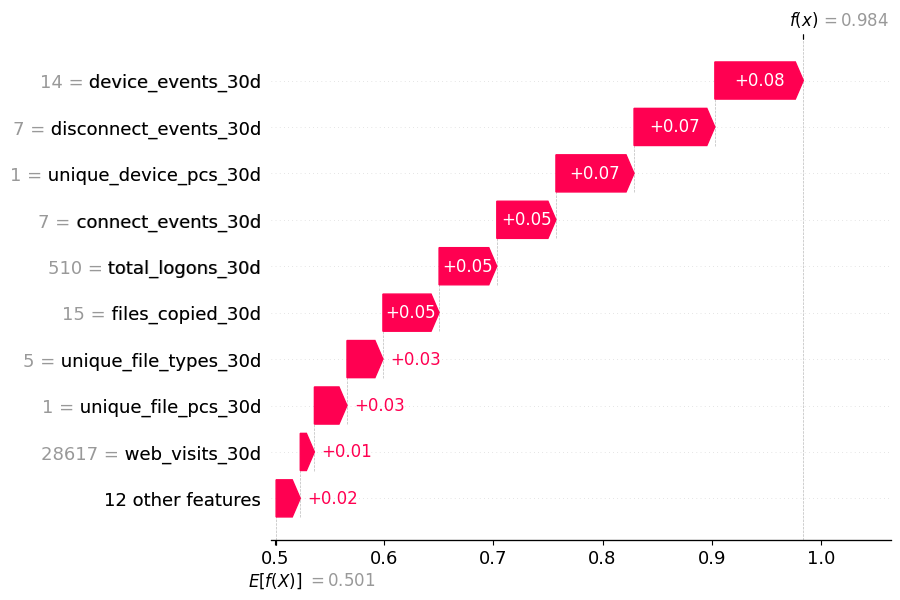

In [139]:
shap.waterfall_plot(
    shap.Explanation(
        values=local_shap,
        base_values=explainer.expected_value[1],
        data=employee_features.values,
        feature_names=X_test.columns
    )
)

### Predictions for All Employees

In [140]:
id="dashboard01"

all_risk_scores = rf_model.predict_proba(
    X
)[:,1]


dashboard_df = employee_df[
    ["user","label"]
].copy()


dashboard_df["risk_score"] = all_risk_scores

### Create Risk Categories

In [141]:
id="dashboard02"

def risk_category(score):

    if score >= 0.80:
        return "High Risk"

    elif score >= 0.50:
        return "Medium Risk"

    else:
        return "Low Risk"


dashboard_df["risk_category"] = (
    dashboard_df["risk_score"]
    .apply(risk_category)
)

In [142]:
id="dashboard03"

dashboard_df.sort_values(
    "risk_score",
    ascending=False
).head(20)

,user,label,risk_score,risk_category
345,FTM0406,1,0.995072,High Risk
509,JMB0308,1,0.990687,High Risk
103,BDV0168,1,0.989835,High Risk
4,AAM0658,1,0.986482,High Risk
630,MAS0025,1,0.986124,High Risk
691,MYD0978,1,0.983975,High Risk
469,IUB0565,1,0.982757,High Risk
361,GHL0460,1,0.982738,High Risk
119,BLS0678,1,0.977072,High Risk
274,DRR0162,1,0.974352,High Risk


In [143]:
id="dashboard04"

dashboard_df["risk_category"].value_counts()

risk_category
Low Risk       930
High Risk       60
Medium Risk     10
Name: count, dtype: int64

### Create Alert Priority

In [145]:
id="dashboard05"

dashboard_df["alert_priority"] = pd.cut(
    dashboard_df["risk_score"],
    bins=[
        0,
        0.3,
        0.6,
        0.8,
        1.0
    ],
    labels=[
        "Normal",
        "Watch",
        "Suspicious",
        "Critical"
    ]
)

In [146]:
dashboard_df.head()

,user,label,risk_score,risk_category,alert_priority
0,AAE0190,0,0.000000,Low Risk,NaN
1,AAF0535,1,0.899584,High Risk,Critical
2,AAF0791,0,0.000000,Low Risk,NaN
3,AAL0706,0,0.000000,Low Risk,NaN
4,AAM0658,1,0.986482,High Risk,Critical


### Confusion Matrix (Random Forest)

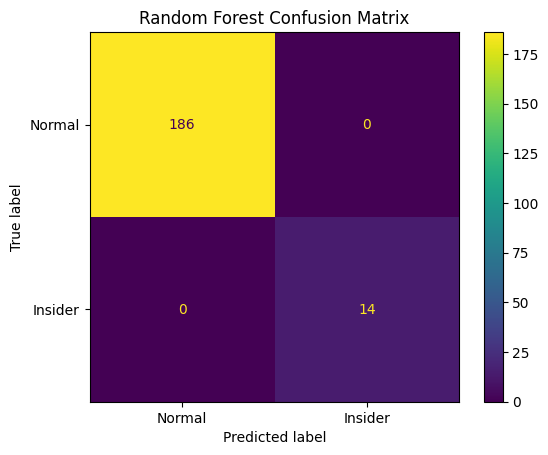

In [147]:
from sklearn.metrics import ConfusionMatrixDisplay


cm = confusion_matrix(
    y_test,
    y_pred_rf
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Insider"
    ]
)


disp.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

### Feature Importance Comparison

In [150]:

feature_compare = pd.DataFrame({

    "Feature": X.columns,

    "RandomForest_Importance":
        rf_model.feature_importances_,

    "SHAP_Importance":
        np.abs(insider_shap).mean(axis=0)

})


feature_compare.sort_values(
    "SHAP_Importance",
    ascending=False
).head(15)

,Feature,RandomForest_Importance,SHAP_Importance
4,unique_device_pcs_30d,0.149140,0.068262
0,total_logons_30d,0.067021,0.055010
3,device_events_30d,0.132423,0.054237
6,disconnect_events_30d,0.130761,0.053788
5,connect_events_30d,0.110752,0.047737
7,files_copied_30d,0.093990,0.044990
9,unique_file_pcs_30d,0.076098,0.034237
12,email_attachments_30d,0.039587,0.032812
8,unique_file_types_30d,0.067175,0.026437
10,emails_sent_30d,0.028396,0.021741


### Employee Risk Ranking

In [151]:
id="risk_report01"

risk_report = dashboard_df.sort_values(
    "risk_score",
    ascending=False
).copy()


risk_report.head(10)

,user,label,risk_score,risk_category,alert_priority
345,FTM0406,1,0.995072,High Risk,Critical
509,JMB0308,1,0.990687,High Risk,Critical
103,BDV0168,1,0.989835,High Risk,Critical
4,AAM0658,1,0.986482,High Risk,Critical
630,MAS0025,1,0.986124,High Risk,Critical
691,MYD0978,1,0.983975,High Risk,Critical
469,IUB0565,1,0.982757,High Risk,Critical
361,GHL0460,1,0.982738,High Risk,Critical
119,BLS0678,1,0.977072,High Risk,Critical
274,DRR0162,1,0.974352,High Risk,Critical


In [152]:
id="risk_report02"

def severity(score):

    if score >= 0.80:
        return "Critical"

    elif score >= 0.60:
        return "High"

    elif score >= 0.30:
        return "Medium"

    else:
        return "Low"


risk_report["severity"] = (
    risk_report["risk_score"]
    .apply(severity)
)

In [153]:
id="risk_report03"

def get_top_reasons(employee_index, top_n=3):

    position = X.index.get_loc(employee_index)

    local_values = insider_shap[position]

    explanation = pd.DataFrame({

        "feature": X.columns,

        "impact": local_values

    })

    explanation["abs_impact"] = (
        explanation["impact"]
        .abs()
    )


    explanation = explanation.sort_values(
        "abs_impact",
        ascending=False
    )


    positive = explanation[
        explanation["impact"] > 0
    ]


    return positive.head(top_n)["feature"].tolist()

In [155]:
# Generate SHAP explanations for all employees

explainer_all = shap.TreeExplainer(
    rf_model
)


shap_all = explainer_all.shap_values(
    X
)

In [156]:
if isinstance(shap_all, list):

    insider_shap_all = shap_all[1]

elif len(np.array(shap_all).shape) == 3:

    insider_shap_all = shap_all[:,:,1]

else:

    insider_shap_all = shap_all.values[:,:,1]


print(insider_shap_all.shape)

(1000, 21)


### Replace Explanation Function

In [157]:
def get_top_reasons(employee_index, top_n=3):

    position = X.index.get_loc(employee_index)

    local_values = insider_shap_all[position]

    explanation = pd.DataFrame({

        "feature": X.columns,

        "impact": local_values

    })


    explanation["abs_impact"] = (
        explanation["impact"]
        .abs()
    )


    explanation = explanation.sort_values(
        "abs_impact",
        ascending=False
    )


    positive = explanation[
        explanation["impact"] > 0
    ]


    return positive.head(top_n)["feature"].tolist()

### Recreate High Risk Explanations

In [158]:
high_risk = risk_report[
    risk_report["risk_score"] >= 0.50
].copy()


high_risk["risk_factors"] = high_risk.index.map(
    get_top_reasons
)


high_risk.head()

,user,label,risk_score,risk_category,alert_priority,severity,risk_factors
345,FTM0406,1,0.995072,High Risk,Critical,Critical,"[device_events_30d, disconnect_events_30d, uni..."
509,JMB0308,1,0.990687,High Risk,Critical,Critical,"[device_events_30d, disconnect_events_30d, uni..."
103,BDV0168,1,0.989835,High Risk,Critical,Critical,"[device_events_30d, disconnect_events_30d, uni..."
4,AAM0658,1,0.986482,High Risk,Critical,Critical,"[device_events_30d, disconnect_events_30d, uni..."
630,MAS0025,1,0.986124,High Risk,Critical,Critical,"[device_events_30d, disconnect_events_30d, uni..."


In [160]:
# Map ML features into realistic insider threat behaviours

feature_mapping = {

    # Access Behaviour
    "total_logons_30d": {
        "category": "Access Behaviour Risk",
        "explanation": "High login activity compared with normal employees"
    },

    "unique_logon_pcs_30d": {
        "category": "Access Behaviour Risk",
        "explanation": "Access to multiple workstations detected"
    },

    "after_hours_logons_30d": {
        "category": "Access Behaviour Risk",
        "explanation": "Login activity occurred outside normal working hours"
    },

    "weekend_logons_30d": {
        "category": "Access Behaviour Risk",
        "explanation": "Weekend access activity detected"
    },


    # Device Behaviour
    "device_events_30d": {
        "category": "Device Usage Risk",
        "explanation": "Elevated device connection activity detected"
    },

    "unique_device_pcs_30d": {
        "category": "Device Usage Risk",
        "explanation": "Multiple devices or machines were accessed"
    },

    "connect_events_30d": {
        "category": "Device Usage Risk",
        "explanation": "Frequent device connections detected"
    },

    "disconnect_events_30d": {
        "category": "Device Usage Risk",
        "explanation": "Frequent device removal activity detected"
    },

    "after_hours_device_30d": {
        "category": "Device Usage Risk",
        "explanation": "Device activity occurred outside business hours"
    },


    # File Behaviour
    "files_copied_30d": {
        "category": "Data Movement Risk",
        "explanation": "Unusual file copying activity detected"
    },

    "unique_file_types_30d": {
        "category": "Data Movement Risk",
        "explanation": "Multiple file categories were accessed"
    },

    "unique_file_pcs_30d": {
        "category": "Data Movement Risk",
        "explanation": "Files were accessed from multiple machines"
    },

    "after_hours_file_30d": {
        "category": "Data Movement Risk",
        "explanation": "File activity occurred outside working hours"
    },


    # Email Behaviour
    "emails_sent_30d": {
        "category": "Communication Risk",
        "explanation": "Unusual email volume detected"
    },

    "external_emails_30d": {
        "category": "Communication Risk",
        "explanation": "Increased communication with external recipients"
    },

    "email_attachments_30d": {
        "category": "Communication Risk",
        "explanation": "Higher attachment activity detected"
    },

    "after_hours_email_30d": {
        "category": "Communication Risk",
        "explanation": "Email activity occurred outside working hours"
    },


    # Web Behaviour
    "web_visits_30d": {
        "category": "Online Activity Risk",
        "explanation": "Unusual web activity volume detected"
    },

    "unique_domains_30d": {
        "category": "Online Activity Risk",
        "explanation": "Access to multiple domains detected"
    },

    "after_hours_web_30d": {
        "category": "Online Activity Risk",
        "explanation": "Web activity occurred outside normal hours"
    }
}

In [161]:
def generate_human_explanation(employee_index, top_n=5):

    position = X.index.get_loc(employee_index)

    local_values = insider_shap_all[position]


    explanation_df = pd.DataFrame({

        "feature": X.columns,

        "shap_value": local_values,

        "feature_value": X.loc[
            employee_index
        ].values

    })


    # only risk increasing factors
    explanation_df = explanation_df[
        explanation_df["shap_value"] > 0
    ]


    explanation_df["impact"] = (
        explanation_df["shap_value"]
        .abs()
    )


    explanation_df = explanation_df.sort_values(
        "impact",
        ascending=False
    )


    results = []


    for _, row in explanation_df.head(top_n).iterrows():

        feature = row["feature"]

        if feature in feature_mapping:

            results.append({

                "Risk Category":
                    feature_mapping[feature]["category"],

                "Behaviour Indicator":
                    feature_mapping[feature]["explanation"],

                "Observed Value":
                    round(row["feature_value"],2),

                "Impact":
                    round(row["shap_value"],3)

            })


    return pd.DataFrame(results)

In [162]:
employee_id = high_risk.index[0]


generate_human_explanation(
    employee_id
)

,Risk Category,Behaviour Indicator,Observed Value,Impact
0,Device Usage Risk,Elevated device connection activity detected,36.0,0.079
1,Device Usage Risk,Frequent device removal activity detected,18.0,0.072
2,Device Usage Risk,Multiple devices or machines were accessed,1.0,0.072
3,Device Usage Risk,Frequent device connections detected,18.0,0.055
4,Access Behaviour Risk,High login activity compared with normal emplo...,498.0,0.053


In [163]:

normal_baseline = X[
    y == 0
].mean()


normal_baseline.head()

total_logons_30d          865.948387
unique_logon_pcs_30d       20.379570
after_hours_logons_30d    342.235484
device_events_30d         388.436559
unique_device_pcs_30d       3.482796
dtype: float64

### Deviation Calculation

In [164]:

def calculate_deviation(
    employee_index,
    feature
):

    employee_value = X.loc[
        employee_index,
        feature
    ]


    normal_value = normal_baseline[
        feature
    ]


    if normal_value == 0:
        return 0


    deviation = (
        employee_value - normal_value
    ) / normal_value


    return deviation

### Human Explanation Function

In [165]:

def generate_human_explanation(
    employee_index,
    top_n=5
):

    position = X.index.get_loc(
        employee_index
    )


    local_values = insider_shap_all[position]


    explanation_df = pd.DataFrame({

        "feature": X.columns,

        "shap_value": local_values,

        "feature_value":
            X.loc[employee_index].values

    })


    explanation_df = explanation_df[
        explanation_df["shap_value"] > 0
    ]


    explanation_df["impact"] = (
        explanation_df["shap_value"]
        .abs()
    )


    explanation_df = explanation_df.sort_values(
        "impact",
        ascending=False
    )


    results = []


    for _, row in explanation_df.head(top_n).iterrows():

        feature = row["feature"]


        if feature in feature_mapping:


            deviation = calculate_deviation(
                employee_index,
                feature
            )


            results.append({

                "Risk Category":
                    feature_mapping[feature]["category"],


                "Behaviour Indicator":
                    feature_mapping[feature]["explanation"],


                "Observed Value":
                    round(row["feature_value"],2),


                "Normal Average":
                    round(
                        normal_baseline[feature],
                        2
                    ),


                "Deviation":
                    f"{round(deviation*100,1)}%",


                "SHAP Impact":
                    round(
                        row["shap_value"],
                        3
                    )

            })


    return pd.DataFrame(results)

In [166]:

employee_id = high_risk.index[0]


generate_human_explanation(
    employee_id
)

,Risk Category,Behaviour Indicator,Observed Value,Normal Average,Deviation,SHAP Impact
0,Device Usage Risk,Elevated device connection activity detected,36.0,388.44,-90.7%,0.079
1,Device Usage Risk,Frequent device removal activity detected,18.0,193.60,-90.7%,0.072
2,Device Usage Risk,Multiple devices or machines were accessed,1.0,3.48,-71.3%,0.072
3,Device Usage Risk,Frequent device connections detected,18.0,194.84,-90.8%,0.055
4,Access Behaviour Risk,High login activity compared with normal emplo...,498.0,865.95,-42.5%,0.053


In [169]:
final_explainable_alerts = []

for employee_id in high_risk.index:

    explanation = generate_human_explanation(
        employee_id
    )

    for _, row in explanation.iterrows():

        final_explainable_alerts.append({

            "user":
                employee_id,

            "risk_score":
                risk_report.loc[
                    employee_id,
                    "risk_score"
                ],

            "risk_category":
                risk_report.loc[
                    employee_id,
                    "risk_category"
                ],

            "alert_priority":
                risk_report.loc[
                    employee_id,
                    "alert_priority"
                ],

            "severity":
                risk_report.loc[
                    employee_id,
                    "severity"
                ],

            "Risk Category":
                row["Risk Category"],

            "Indicator":
                row["Behaviour Indicator"],

            "Observed":
                row["Observed Value"],

            "Normal Avg":
                row["Normal Average"],

            "Deviation":
                row["Deviation"],

            "SHAP Impact":
                row["SHAP Impact"]

        })

In [170]:
final_explainable_alerts = pd.DataFrame(
    final_explainable_alerts
)

In [171]:
final_explainable_alerts.head(20)

,user,risk_score,risk_category,alert_priority,severity,Risk Category,Indicator,Observed,Normal Avg,Deviation,SHAP Impact
0,345,0.995072,High Risk,Critical,Critical,Device Usage Risk,Elevated device connection activity detected,36.0,388.44,-90.7%,0.079
1,345,0.995072,High Risk,Critical,Critical,Device Usage Risk,Frequent device removal activity detected,18.0,193.60,-90.7%,0.072
2,345,0.995072,High Risk,Critical,Critical,Device Usage Risk,Multiple devices or machines were accessed,1.0,3.48,-71.3%,0.072
3,345,0.995072,High Risk,Critical,Critical,Device Usage Risk,Frequent device connections detected,18.0,194.84,-90.8%,0.055
4,345,0.995072,High Risk,Critical,Critical,Access Behaviour Risk,High login activity compared with normal emplo...,498.0,865.95,-42.5%,0.053
5,509,0.990687,High Risk,Critical,Critical,Device Usage Risk,Elevated device connection activity detected,16.0,388.44,-95.9%,0.081
6,509,0.990687,High Risk,Critical,Critical,Device Usage Risk,Frequent device removal activity detected,8.0,193.60,-95.9%,0.075
7,509,0.990687,High Risk,Critical,Critical,Device Usage Risk,Multiple devices or machines were accessed,1.0,3.48,-71.3%,0.071
8,509,0.990687,High Risk,Critical,Critical,Device Usage Risk,Frequent device connections detected,8.0,194.84,-95.9%,0.054
9,509,0.990687,High Risk,Critical,Critical,Access Behaviour Risk,High login activity compared with normal emplo...,314.0,865.95,-63.7%,0.053


### Temporal Early Detection Validation (Lead Time Analysis)

In [172]:

insider_windows.head()

,user,scenario,start,end,window_start,window_end
0,ONS0995,1,2010-03-06 01:41:56,2010-03-20 08:10:12,2010-02-04 01:41:56,2010-03-06 01:41:56
1,CSF0929,1,2010-07-01 01:24:58,2010-07-16 06:52:00,2010-06-01 01:24:58,2010-07-01 01:24:58
2,CCH0959,2,2010-08-02 10:34:31,2010-09-30 15:04:03,2010-07-03 10:34:31,2010-08-02 10:34:31
3,RCW0822,1,2010-09-29 21:10:27,2010-10-15 06:34:52,2010-08-30 21:10:27,2010-09-29 21:10:27
4,JCE0258,2,2010-07-12 08:16:02,2010-09-03 16:16:29,2010-06-12 08:16:02,2010-07-12 08:16:02


### Calculate Detection Lead Time

In [173]:

lead_time_results = []

for _, row in insider_windows.iterrows():

    employee = row["user"]

    prediction_date = row["window_end"]

    insider_date = row["end"]


    lead_days = (
        insider_date -
        prediction_date
    ).days


    lead_time_results.append({

        "user": employee,

        "prediction_date":
            prediction_date,

        "incident_date":
            insider_date,

        "lead_days":
            lead_days

    })


lead_time_df = pd.DataFrame(
    lead_time_results
)


lead_time_df.head()

,user,prediction_date,incident_date,lead_days
0,ONS0995,2010-03-06 01:41:56,2010-03-20 08:10:12,14
1,CSF0929,2010-07-01 01:24:58,2010-07-16 06:52:00,15
2,CCH0959,2010-08-02 10:34:31,2010-09-30 15:04:03,59
3,RCW0822,2010-09-29 21:10:27,2010-10-15 06:34:52,15
4,JCE0258,2010-07-12 08:16:02,2010-09-03 16:16:29,53


In [174]:

lead_time_df["lead_days"].describe()

count    190.000000
mean      32.663158
std       30.532699
min        0.000000
25%        5.000000
50%       37.000000
75%       57.000000
max      159.000000
Name: lead_days, dtype: float64

In [175]:
import joblib
import os

os.makedirs("models", exist_ok=True)


# Save trained model
joblib.dump(
    rf_model,
    "models/random_forest_model.pkl"
)


# Save feature list
joblib.dump(
    X.columns.tolist(),
    "models/feature_columns.pkl"
)


print("Models saved successfully")

Models saved successfully


In [177]:
id="risk_dist_fix"

risk_distribution = (
    dashboard_df["risk_category"]
    .value_counts()
    .reset_index()
)


risk_distribution.columns = [
    "Risk Level",
    "Employees"
]


risk_distribution

,Risk Level,Employees
0,Low Risk,930
1,High Risk,60
2,Medium Risk,10


In [178]:
id="export_fix"

import os

os.makedirs(
    "data",
    exist_ok=True
)


dashboard_df.to_csv(
    "data/employee_risk_scores.csv",
    index=False
)


final_explainable_alerts.to_csv(
    "data/final_explainable_alerts.csv",
    index=False
)


risk_distribution.to_csv(
    "data/risk_distribution.csv",
    index=False
)


lead_time_df.to_csv(
    "data/lead_time_results.csv",
    index=False
)


print("All dashboard files exported successfully")

All dashboard files exported successfully


In [179]:
id="verify_files"

import os

for file in [
    "employee_risk_scores.csv",
    "final_explainable_alerts.csv",
    "risk_distribution.csv",
    "lead_time_results.csv"
]:

    print(
        file,
        os.path.exists(
            "data/" + file
        )
    )

employee_risk_scores.csv True
final_explainable_alerts.csv True
risk_distribution.csv True
lead_time_results.csv True


In [180]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [181]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [182]:
X = model_df.drop(
    columns=[
        "user",
        "window_start",
        "window_end",
        "label"
    ]
)


y = model_df["label"]

In [183]:
rf_cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=False
)

In [184]:
rf_cv_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Mean Score":[

        rf_cv_results["test_accuracy"].mean(),

        rf_cv_results["test_precision"].mean(),

        rf_cv_results["test_recall"].mean(),

        rf_cv_results["test_f1"].mean(),

        rf_cv_results["test_roc_auc"].mean()

    ],

    "Std":[

        rf_cv_results["test_accuracy"].std(),

        rf_cv_results["test_precision"].std(),

        rf_cv_results["test_recall"].std(),

        rf_cv_results["test_f1"].std(),

        rf_cv_results["test_roc_auc"].std()

    ]

})


rf_cv_summary

,Metric,Mean Score,Std
0,Accuracy,0.892857,0.039123
1,Precision,0.851695,0.054841
2,Recall,0.957143,0.034993
3,F1 Score,0.900078,0.033782
4,ROC-AUC,0.982653,0.008896
